In [1]:
'''
Read in species counts by group to create background points instead of doing it by species.
'''

'\nRead in species counts by group to create background points instead of doing it by species.\n'

In [1]:
import os
import pandas as pd
from pathlib import Path
import glob
import polars as pl
import json
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
from rasterio.transform import from_origin
import rasterio
from rasterio.io import MemoryFile
import elapid
import geopandas as gpd
import warnings
warnings.filterwarnings("ignore")

In [2]:
parambasedir =  '/mnt/f/readyparams/param_csvs'
outputdir = '/mnt/f/readyparams/param_csvs'
aoi = 'mav_counties_4326.parquet'
aoi = gpd.read_parquet(os.path.join(parambasedir,aoi))
avian_list = [
    "Protonotaria citrea",
    "Limnothlypis swainsonii",
    "Setophaga americana",
    "Empidonax virescens",
    "Coccyzus americanus",
    "Vireo griseus",
    "Setophaga cerulea",
    "Hylocichla mustelina",
    "Parkesia motacilla",
    "Geothlypis formosa",
    "Archilochus colubris",
    "Elanoides forficatus",
    "Vireo flavifrons",
    "Buteo lineatus",
    "Setophaga dominica",
    "Setophaga citrina",
    "Dryocopus pileatus",
    "Meleagris gallopavo",
    "Sphyrapicus varius" 
    ]

herp_list = [
    "Anaxyrus americanus",        # American Toad
    "Anaxyrus fowleri",           # Fowler's Toad
    "Gastrophryne carolinensis",  # Eastern Narrow-mouthed Toad
    "Hyla avivoca",               # Bird-voiced Treefrog
    "Hyla chrysoscelis",          # Cope's Gray Treefrog
    "Hyla cinerea",               # Green Treefrog
    "Hyla squirella",             # Squirrel Treefrog    
    "Hyla versicolor",            # Gray Treefrog
    "Lithobates catesbeianus",    # American Bullfrog
    "Lithobates clamitans",       # Bronze Frog
    "Lithobates palustris",       # Pickerel Frog
    "Lithobates sphenocephalus",  # Southern Leopard Frog
    "Pseudacris crucifer",        # Spring Peeper
    "Pseudacris fouquettei",      # Cajun Chorus Frog
    "Kinosternon subrubrum",      # Eastern Mud Turtle
    "Apalone spinifera",          # Spiny Softshell Turtle   
    "Macrochelys temmincki"       # Alligator Snapping Turtle    
    ]

mammal_list = [
    "Odocoileus virginianus",     # white tailed deer
    "Ursus americanus"            # Black bear 
    ]

In [15]:
holdlists = {}
cursp = ''
for index, spl in enumerate([avian_list, herp_list, mammal_list]):
    match index:
        case 0:
            print('running avian')
            cursp = 'avian'
        case 1:
            print('running herp')
            cursp = 'herp'
        case 2:
            print('running mammal')
            cursp = 'mammal'
    combined_df = pd.DataFrame()
    csv_files = None
    print(cursp)
    for sp in spl:
        print(sp)
        sp = sp.lower().replace(' ', '_')
        # Find matching files
        csv_files = glob.glob(os.path.join(parambasedir, f"*{sp}*.csv"))
        dfs = []
        if len(csv_files) == 0:
            continue
        print(csv_files)
        for file_path in csv_files:
            # Read CSV
            df = pl.read_csv(file_path)
            # Extract lon/lat
            df = df.with_columns([
                pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][0], return_dtype=pl.Float64).alias("longitude"),
                pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][1], return_dtype=pl.Float64).alias("latitude")
            ])
            
            # Drop unnecessary columns
            df = df.drop(["system:index", ".geo"])
            
            
            dfs.append(df)
            
        combined_df = pl.concat(dfs, how='diagonal')
        combined_df = combined_df.with_columns(
            pl.lit(1).alias("label")  # constant string
        )
    
    holdlists[cursp]=combined_df


running avian
avian
Protonotaria citrea
['/mnt/f/readyparams/param_csvs/protonotaria_citrea_subset0.csv', '/mnt/f/readyparams/param_csvs/protonotaria_citrea_subset1.csv']
Limnothlypis swainsonii
['/mnt/f/readyparams/param_csvs/limnothlypis_swainsonii_subset0.csv', '/mnt/f/readyparams/param_csvs/limnothlypis_swainsonii_subset1.csv']
Setophaga americana
['/mnt/f/readyparams/param_csvs/setophaga_americana_subset0.csv', '/mnt/f/readyparams/param_csvs/setophaga_americana_subset1.csv']
Empidonax virescens
['/mnt/f/readyparams/param_csvs/empidonax_virescens_subset0.csv', '/mnt/f/readyparams/param_csvs/empidonax_virescens_subset1.csv']
Coccyzus americanus
['/mnt/f/readyparams/param_csvs/coccyzus_americanus_subset0.csv', '/mnt/f/readyparams/param_csvs/coccyzus_americanus_subset1.csv']
Vireo griseus
['/mnt/f/readyparams/param_csvs/vireo_griseus_subset0.csv', '/mnt/f/readyparams/param_csvs/vireo_griseus_subset1.csv']
Setophaga cerulea
['/mnt/f/readyparams/param_csvs/setophaga_cerulea_subset0.csv'

In [16]:
csv_files = glob.glob(os.path.join(parambasedir, f"background_pts.csv"))

bgs = []
for file_path in csv_files:
    print(f"Reading: {file_path}")

    # Read CSV
    bg = pl.read_csv(file_path)
    # Extract lon/lat
    bg = bg.with_columns([
        pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][0], return_dtype=pl.Float64).alias("longitude"),
        pl.col(".geo").map_elements(lambda x: json.loads(x)["coordinates"][1], return_dtype=pl.Float64).alias("latitude")
    ])
    # Drop unnecessary columns
    bg = bg.drop(["system:index", ".geo"])
    bgs.append(bg)
    
combined_bg = pl.concat(bgs, how='diagonal')
combined_bg = combined_bg.with_columns(
    pl.lit(0).alias("label")  # constant string
)
print(len(combined_bg))

Reading: /mnt/f/readyparams/param_csvs/background_pts.csv
29326


In [20]:
holdlists.keys()

dict_keys(['avian', 'herp', 'mammal'])

avian


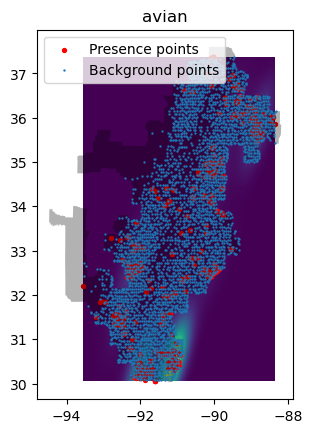

Total presence points: 2178
Total background points: 3728
#########

herp


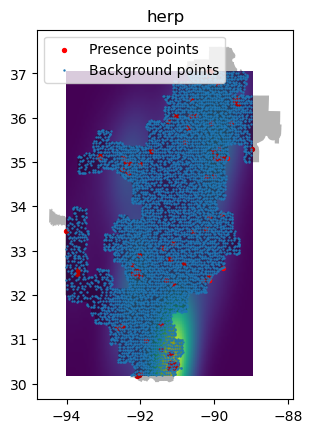

Total presence points: 157
Total background points: 5241
#########

mammal


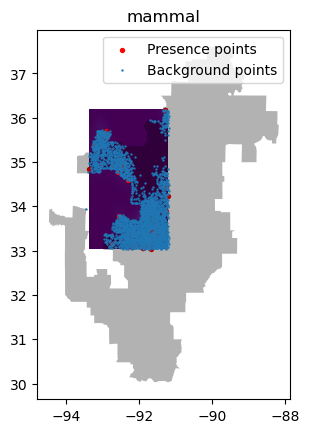

Total presence points: 225
Total background points: 2219
#########



In [46]:
for key in holdlists:

    print(key)
    combined_df = holdlists[key]
    x = combined_df["longitude"]
    y = combined_df["latitude"]
    xy = np.vstack([x,y])
    kde = stats.gaussian_kde(xy)
    # To get density at specific points (e.g., a grid for plotting)
    # Create a meshgrid
    xmin, ymin = x.min(), y.min()
    xmax, ymax = x.max(), y.max()
    X, Y = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
    # Evaluate the KDE on the grid
    Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)
    fig, ax = plt.subplots()
    plt.imshow(Z, extent=[xmin, xmax, ymin, ymax], origin='lower', cmap='viridis')
    plt.scatter(x, y, s=8, c='red')
    xres = (xmax - xmin) / Z.shape[1]
    yres = (ymax - ymin) / Z.shape[0]
    transform = from_origin(xmin, ymax, xres, yres)
    
    Z_clean = np.nan_to_num(Z, nan=0.0)
    Z_clean[Z_clean < 0] = 0.0
    Z_raster = np.flipud(Z_clean)  # <-- important
    
    with rasterio.Env():
        with MemoryFile() as memfile:
            with memfile.open(
                driver="GTiff",
                height=Z_raster.shape[0],
                width=Z_raster.shape[1],
                count=1,
                dtype=Z_raster.dtype,
                crs="EPSG:4326",
                transform=transform,
            ) as dataset:
                dataset.write(Z_raster, 1)
    
            vsi_path = memfile.name
            pseudoabsence_bias = elapid.sample_bias_file(vsi_path, 25000)
    
    # done; no files written to disk
    #pseudoabsence_bias.plot(markersize=0.5)

    geometry = gpd.points_from_xy(combined_bg["longitude"], combined_bg["latitude"])
    bgdf = gpd.GeoDataFrame(combined_bg.to_pandas().copy(), geometry=geometry, crs="EPSG:4326")
    pseudo = gpd.GeoDataFrame(geometry=pseudoabsence_bias, crs="EPSG:4326")
    
    
    A_with_nearest_B = gpd.sjoin_nearest(
        pseudo,bgdf,
        how="left",             # keep all A rows
        distance_col="dist_m"   # name the output distance column
    )
    
    # ---- Remove duplicates (keep only unique B points) ----
    unique_b_idxs = (
        A_with_nearest_B["index_right"]
        .dropna()
        .astype(int)
        .unique()
    )
    B_for_each_A = bgdf.loc[unique_b_idxs].reset_index(drop=True)
    plt.title(f"{key}")
    aoi.plot(ax=ax, color='black', alpha=0.3) 
    B_for_each_A.plot(ax=ax,markersize=0.5)
    plt.legend(['Presence points', 'Background points'])
    plt.show()
    plt.close()
    
    print('Total presence points:',len(combined_df))
    print('Total background points:',len(B_for_each_A))
    #[avian_list, herp_list, mammal_list]
    '''
    match index:
        case 0:
            B_for_each_A.to_csv(os.path.join(outputdir, f"background_avian.csv"), index=False)
        case 1:
            B_for_each_A.to_csv(os.path.join(outputdir, f"background_herp.csv"), index=False)
        case 2:
            B_for_each_A.to_csv(os.path.join(outputdir, f"background_mammal.csv"), index=False)
    '''
    print('#########')
    print('')